<a href="https://colab.research.google.com/github/Graciliana/Heart-disease-prediction/blob/main/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pré-processamento

## 1. Objetivo

Esta etapa iremos realizar os tratamento dos dados.

## 2. Importação das bibliotecas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.ticker import PercentFormatter

import plotly.express as px

from scipy.stats import skew
from IPython.display import Markdown

import os
import math
import glob

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

## 3. Configuração de ambiente

In [2]:
RANDOM_STATE = 42

JADE = "#00A93F"

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 100)

## 4. Carregamento dos dados

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/raw/heart_2020_cleaned.csv")

In [4]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


## 5. Separação das variáveis

In [5]:
# @title Definição da variável alvo
TARGET = "HeartDisease"
print(f"Variável alvo: {TARGET}")

Variável alvo: HeartDisease


In [6]:
# @title Identificação das variáveis numéricas e categóricas
numeric_columns = (
    df
    .select_dtypes(include=["int64", "float64"])
    .columns
    .drop(TARGET, errors="ignore")
    .tolist()
)

categorical_columns = (
    df
    .select_dtypes(include=["object", "category", "bool"])
    .columns
    .drop(TARGET, errors="ignore")
    .tolist()
)

In [7]:
# @title Resumo das variáveis
print("=" * 50)
print("RESUMO DAS VARIÁVEIS")
print("=" * 50)

print(f"Variável alvo            : {TARGET}")

print(f"Variáveis numéricas      : {len(numeric_columns)}")

print(f"Variáveis categóricas    : {len(categorical_columns)}")

RESUMO DAS VARIÁVEIS
Variável alvo            : HeartDisease
Variáveis numéricas      : 4
Variáveis categóricas    : 13


In [8]:
# @title Listagem das variaveis
print("=" * 50)
print("VARIÁVEIS NUMÉRICAS")
print("=" * 50)

numeric_df = pd.DataFrame({
    "Variáveis Numéricas": numeric_columns
})

display(numeric_df)

print("=" * 50)
print("VARIÁVEIS CATEGÓRICAS")
print("=" * 50)

categorical_df = pd.DataFrame({
    "Variáveis Categóricas": categorical_columns
})

display(categorical_df)

VARIÁVEIS NUMÉRICAS


,Variáveis Numéricas
0,BMI
1,PhysicalHealth
2,MentalHealth
3,SleepTime


VARIÁVEIS CATEGÓRICAS


,Variáveis Categóricas
0,Smoking
1,AlcoholDrinking
2,Stroke
3,DiffWalking
4,Sex
5,AgeCategory
6,Race
7,Diabetic
8,PhysicalActivity
9,GenHealth


In [9]:
# @title Resumo completo das variáveis
display(Markdown(f"**Resumo completo das variáveis**"))

summary_variables = pd.DataFrame({
    "Variável": df.columns,
    "Tipo": df.dtypes.astype(str).values,
    "Valores Únicos": [df[col].nunique() for col in df.columns],
    "Valores Ausentes": [df[col].isna().sum() for col in df.columns]
})

display(summary_variables)

**Resumo completo das variáveis**

,Variável,Tipo,Valores Únicos,Valores Ausentes
0,HeartDisease,object,2,0
1,BMI,float64,3604,0
2,Smoking,object,2,0
3,AlcoholDrinking,object,2,0
4,Stroke,object,2,0
5,PhysicalHealth,float64,31,0
6,MentalHealth,float64,31,0
7,DiffWalking,object,2,0
8,Sex,object,2,0
9,AgeCategory,object,13,0


#### Principais observações

- A variável alvo do problema é HeartDisease.
- As variáveis foram separadas automaticamente em numéricas e categóricas, facilitando as etapas de pré-processamento.
- As variáveis numéricas serão avaliadas quanto ao escalonamento e tratamento de outliers.
- As variáveis categóricas serão codificadas para permitir seu uso pelos algoritmos de Machine Learning.

## 6. Tratamento de valores ausentes

In [10]:


# @title Quantidade de dados nullos
display(Markdown("### Quantidade de dados nullos"))
display(df.isnull().sum())



### Quantidade de dados nullos

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


> Não possue valores ausentes, não precisando fazer nenhum tratamento

## 7. Tratamento de registros duplicados

In [11]:
duplicates = df.duplicated().sum()
display(Markdown("### Registros Duplicados"))
print(f"Registros duplicados: {duplicates}")

### Registros Duplicados

Registros duplicados: 18078


In [12]:
display(Markdown("### Percentual duplicados"))
print(
    f"Percentual: "
    f"{duplicates/len(df)*100:.2f}%"
)



### Percentual duplicados

Percentual: 5.65%


In [13]:
df = df.drop_duplicates()

> removido os dados duplicados representa 5.65% dos dados não comprometendo os dados.

## Tratamento de outliers

In [14]:
def outlier_analysis(
    df: pd.DataFrame,
    columns: list[str] | None = None
) -> pd.DataFrame:
    """
    Analisa outliers das variáveis numéricas pelo método IQR.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    columns : list[str], optional
        Variáveis numéricas a serem analisadas.

    Returns
    -------
    pandas.DataFrame
        Resumo dos limites e quantidade de outliers.
    """

    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    results = []

    for col in columns:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        mask = (
            (df[col] < lower_limit) |
            (df[col] > upper_limit)
        )

        n_outliers = mask.sum()

        results.append({
            "Variável": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Limite inferior": lower_limit,
            "Limite superior": upper_limit,
            "Outliers": n_outliers,
            "Outliers (%)": n_outliers / len(df) * 100
        })

    return (
        pd.DataFrame(results)
        .sort_values("Outliers (%)", ascending=False)
        .reset_index(drop=True)
    )

In [15]:
outlier_analysis_df = outlier_analysis(
    df,
    numeric_columns
)

display(
    outlier_analysis_df.round(2)
)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers,Outliers (%)
0,PhysicalHealth,0.00,2.00,2.00,-3.0,5.00,47136,15.62
1,MentalHealth,0.00,4.00,4.00,-6.0,10.00,39713,13.16
2,BMI,24.03,31.65,7.62,12.6,43.08,8905,2.95
3,SleepTime,6.00,8.00,2.00,3.0,11.00,4542,1.51


In [16]:
# @title Visualizar os outliers
JADE = "#00A93F"

def plot_numeric_variables(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    bins: int = 30,
    figsize: tuple = (14, 5),
) -> None:
    """
    Gera um histograma e um boxplot lado a lado para cada variável numérica.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    columns : list[str], optional
        Lista das colunas numéricas. Caso None,
        todas as colunas numéricas serão utilizadas.

    bins : int
        Número de classes do histograma.

    figsize : tuple
        Tamanho da figura.
    """

    if columns is None:
        columns = df.select_dtypes(include="number").columns

    for col in columns:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=figsize,
            gridspec_kw={"width_ratios": [4, 1]}
        )

        # Histograma
        sns.histplot(
            data=df,
            x=col,
            bins=bins,
            kde=True,
            color=JADE,
            alpha=0.85,
            ax=axes[0]
        )
        axes[0].axvline(df[col].mean(), color="red", linestyle="--", label="Média")
        axes[0].axvline(df[col].median(), color="blue", label="Mediana")
        axes[0].legend()
        axes[0].set_title(f"Histograma - {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frequência")

        # Boxplot
        sns.boxplot(
            data=df,
            y=col,
            color=JADE,
            width=0.4,
            ax=axes[1]
        )

        axes[1].set_title(f"Boxplot - {col}")
        axes[1].set_ylabel(col)

        plt.suptitle(
            f"Distribuição da Variável {col}",
            fontsize=15,
            fontweight="bold"
        )

        plt.tight_layout()

        plt.show()


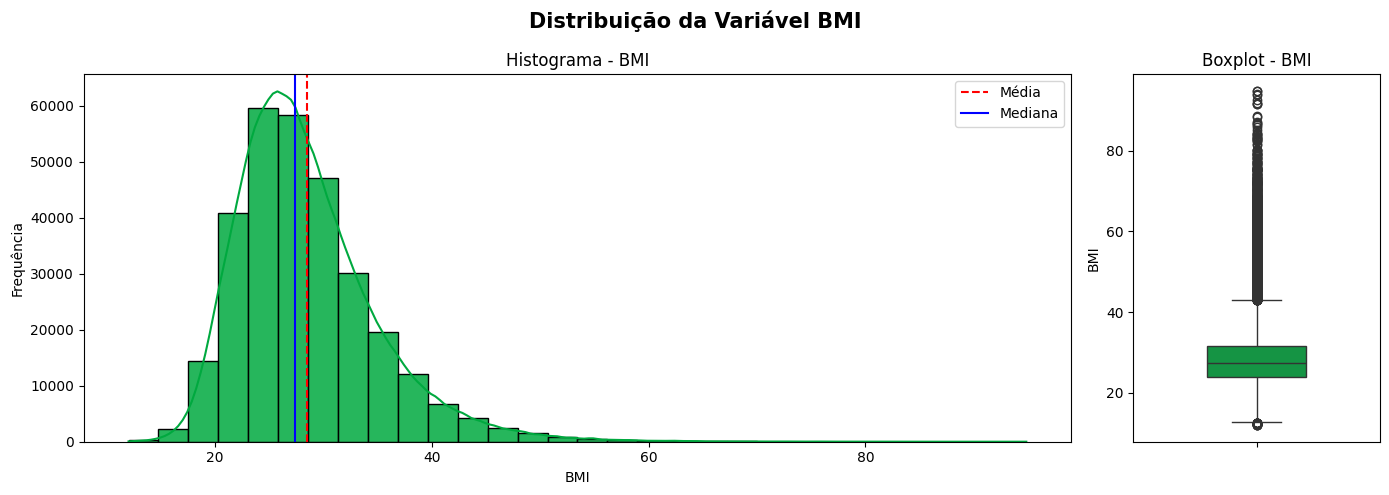

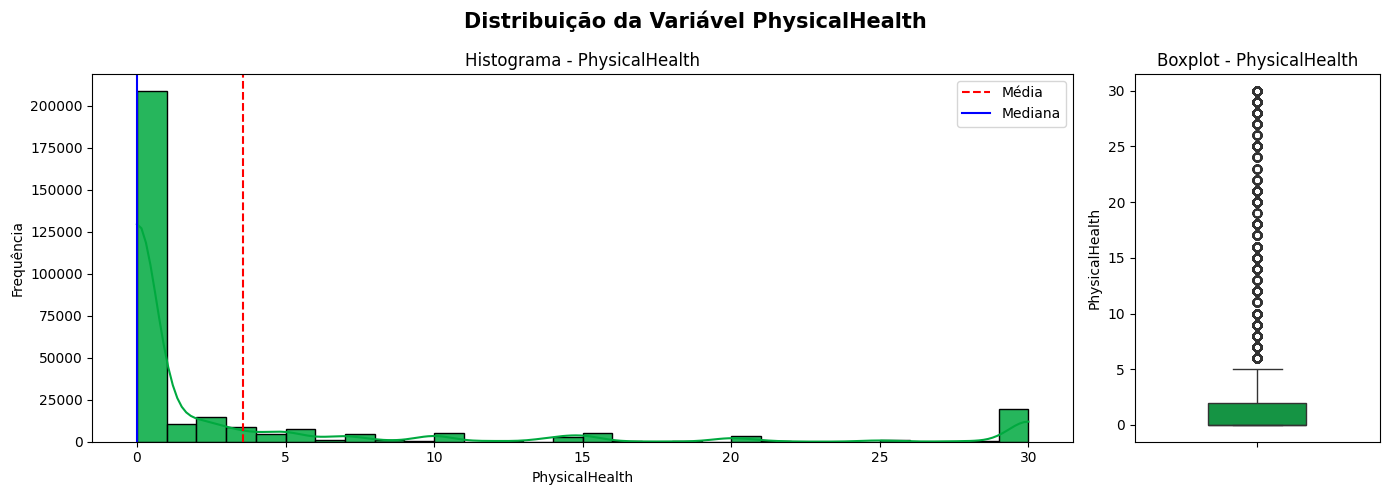

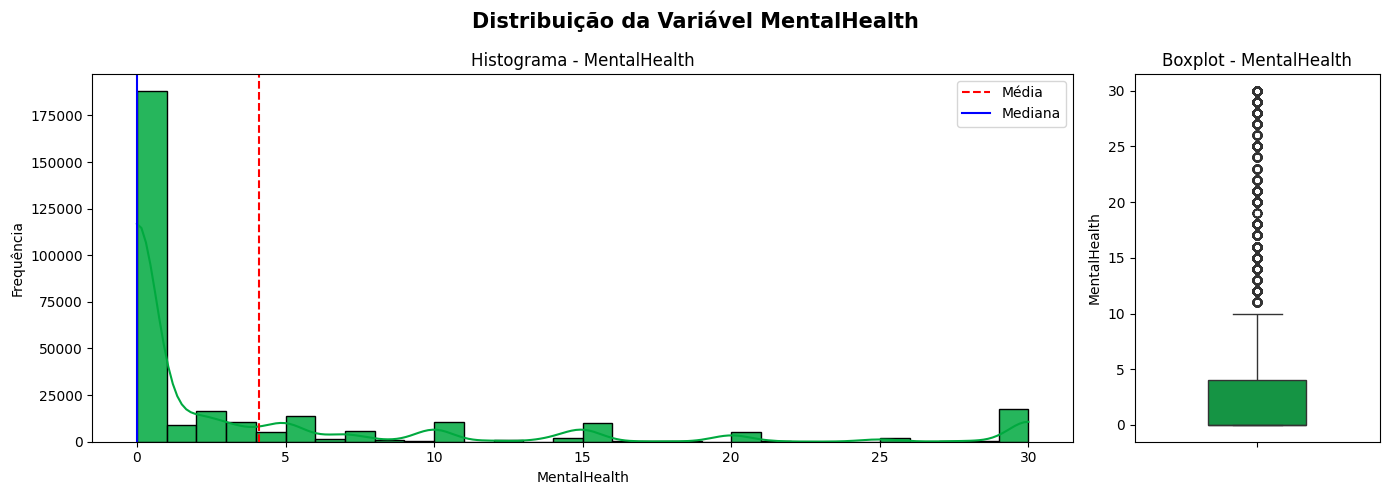

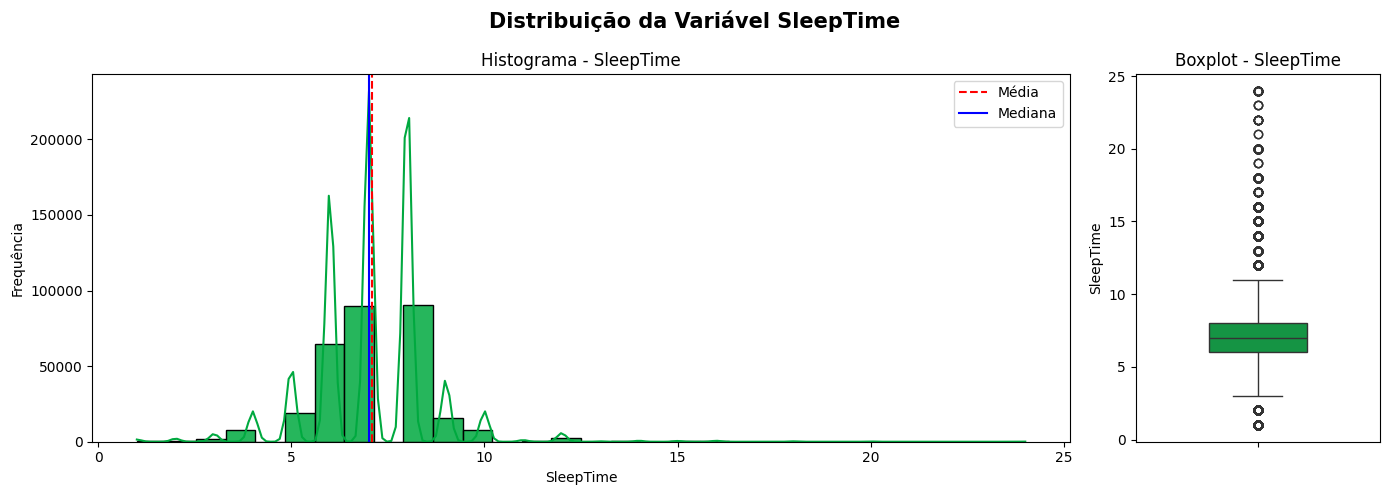

In [17]:

numeric_columns = [
    "BMI",
    "PhysicalHealth",
    "MentalHealth",
    "SleepTime"
]

plot_numeric_variables(df, numeric_columns)

In [18]:
for col in numeric_columns:

    print(f"\n{'=' * 60}")
    print(f"Variável: {col}")
    print(f"{'=' * 60}")

    display(
        df[col]
        .sort_values()
        .head(10)
    )

    display(
        df[col]
        .sort_values(ascending=False)
        .head(10)
    )


Variável: BMI


,BMI
69662,12.02
205511,12.02
113373,12.08
51637,12.13
81754,12.16
77250,12.20
76270,12.21
112289,12.26
253451,12.27
210628,12.40


,BMI
126896,94.85
242834,94.66
104267,93.97
249715,93.86
156093,92.53
126661,91.82
105476,91.55
114087,91.55
229007,88.60
290183,88.19



Variável: PhysicalHealth


,PhysicalHealth
156801,0.0
271653,0.0
271652,0.0
271651,0.0
271681,0.0
271680,0.0
156781,0.0
156779,0.0
156778,0.0
156774,0.0


...

,MentalHealth
319781,0.0
319779,0.0
319778,0.0
319777,0.0
18,0.0
15,0.0
13,0.0
12,0.0
11,0.0
10,0.0


,MentalHealth
25,30.0
0,30.0
23,30.0
319760,30.0
17,30.0
319754,30.0
51989,30.0
145472,30.0
145470,30.0
145443,30.0



Variável: SleepTime


,SleepTime
32533,1.0
254713,1.0
299180,1.0
126070,1.0
116547,1.0
159071,1.0
126389,1.0
116403,1.0
234928,1.0
240567,1.0


,SleepTime
309745,24.0
15736,24.0
90985,24.0
37508,24.0
225626,24.0
52970,24.0
191913,24.0
310560,24.0
223641,24.0
44608,24.0


### Decisão sobre os outliers

A análise dos valores extremos das variáveis numéricas foi realizada utilizando o método do Intervalo Interquartil (IQR), complementado pela análise dos boxplots e das distribuições das variáveis.

Embora tenham sido identificados valores classificados estatisticamente como outliers, esses registros foram considerados plausíveis dentro do contexto do conjunto de dados de saúde. Não foram identificados indícios suficientes de erros de medição, inconsistências ou valores impossíveis que justificassem sua remoção.

Dessa forma, os outliers serão mantidos no conjunto de dados, preservando a variabilidade natural da população analisada e evitando a exclusão arbitrária de observações potencialmente relevantes.

In [19]:
df_processed = df.copy()

print(
    "Outliers: mantidos após análise de plausibilidade."
)


Outliers: mantidos após análise de plausibilidade.


## 9. Codificação das variáveis categóricas

In [20]:
# @title Separar X e y
# =====================================================
# Separação entre variáveis preditoras e variável alvo
# =====================================================

TARGET = "HeartDisease"

X = df_processed.drop(columns=[TARGET])

y = df_processed[TARGET].copy()

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (301717, 17)
Dimensões de y: (301717,)


In [21]:
# @title Codificar a variável alvo
# =====================================================
# Codificação da variável alvo
# =====================================================

target_mapping = {
    "No": 0,
    "Yes": 1
}

y = y.map(target_mapping)

print("Mapeamento da variável alvo:")
print(target_mapping)

print("\nDistribuição do target:")
display(y.value_counts().sort_index())

Mapeamento da variável alvo:
{'No': 0, 'Yes': 1}

Distribuição do target:


,count
HeartDisease,
0,274456
1,27261


In [22]:
if y.isna().any():
    print("⚠️ Existem valores não mapeados na variável alvo.")
else:
    print("✓ Variável alvo codificada corretamente.")

✓ Variável alvo codificada corretamente.


In [23]:
# @title Identificar as categorias
categorical_columns = (
    X
    .select_dtypes(
        include=["object", "category", "bool"]
    )
    .columns
    .tolist()
)

numeric_columns = (
    X
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

print(f"Variáveis numéricas: {len(numeric_columns)}")
print(f"Variáveis categóricas: {len(categorical_columns)}")

Variáveis numéricas: 4
Variáveis categóricas: 13


In [24]:
display(
    pd.DataFrame({
        "Variáveis categóricas": categorical_columns
    })
)

,Variáveis categóricas
0,Smoking
1,AlcoholDrinking
2,Stroke
3,DiffWalking
4,Sex
5,AgeCategory
6,Race
7,Diabetic
8,PhysicalActivity
9,GenHealth


In [25]:
# @title Verificar as categorias antes do encoding
for col in categorical_columns:

    print(f"\n{'=' * 60}")
    print(f"Variável: {col}")
    print(f"{'=' * 60}")

    print(f"Quantidade de categorias: {X[col].nunique()}")

    print("Categorias:")
    print(X[col].dropna().unique())


Variável: Smoking
Quantidade de categorias: 2
Categorias:
['Yes' 'No']

Variável: AlcoholDrinking
Quantidade de categorias: 2
Categorias:
['No' 'Yes']

Variável: Stroke
Quantidade de categorias: 2
Categorias:
['No' 'Yes']

Variável: DiffWalking
Quantidade de categorias: 2
Categorias:
['No' 'Yes']

Variável: Sex
Quantidade de categorias: 2
Categorias:
['Female' 'Male']

Variável: AgeCategory
Quantidade de categorias: 13
Categorias:
['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29']

Variável: Race
Quantidade de categorias: 6
Categorias:
['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']

Variável: Diabetic
Quantidade de categorias: 4
Categorias:
['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)']

Variável: PhysicalActivity
Quantidade de categorias: 2
Categorias:
['Yes' 'No']

Variável: GenHealth
Quantidade de categorias: 5
Categorias:
['Very good' 'Fair' 'Good' 'Poor' 'Excellent']

Va

In [26]:
# @title Criar o OneHotEncoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
print("✓ OneHotEncoder configurado.")

✓ OneHotEncoder configurado.


In [27]:
# @title Ajustar o encoder somente no treinamento
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")

X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)

Dimensões de X_train: (241373, 17)
Dimensões de X_test: (60344, 17)


In [28]:
# @title obter os nomes das novas colunas
encoded_columns = encoder.get_feature_names_out(
    categorical_columns
)

print(
    f"Quantidade de novas variáveis categóricas: "
    f"{len(encoded_columns)}"
)

Quantidade de novas variáveis categóricas: 46


In [29]:
display(
    pd.DataFrame({
        "Variáveis codificadas": encoded_columns
    })
)

,Variáveis codificadas
0,Smoking_No
1,Smoking_Yes
2,AlcoholDrinking_No
3,AlcoholDrinking_Yes
4,Stroke_No
5,Stroke_Yes
6,DiffWalking_No
7,DiffWalking_Yes
8,Sex_Female
9,Sex_Male


In [30]:
# @title Transformar em DataFrame
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

print(f"Dimensões de X_train_encoded_df: {X_train_encoded_df.shape}")
print(f"Dimensões de X_test_encoded_df: {X_test_encoded_df.shape}")

Dimensões de X_train_encoded_df: (241373, 46)
Dimensões de X_test_encoded_df: (60344, 46)


In [31]:
# @title Preservar as variáveis numéricas
X_train_numeric = X_train[numeric_columns].copy()
X_test_numeric = X_test[numeric_columns].copy()

In [32]:
# @title Combinar numéricas e categóricas
X_train_processed = pd.concat(
    [
        X_train_numeric,
        X_train_encoded_df
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test_numeric,
        X_test_encoded_df
    ],
    axis=1
)


In [33]:
print("=" * 60)
print("RESULTADO DO PRÉ-PROCESSAMENTO CATEGÓRICO")
print("=" * 60)

print(f"X_train original : {X_train.shape}")
print(f"X_train processado: {X_train_processed.shape}")

print()

print(f"X_test original  : {X_test.shape}")
print(f"X_test processado : {X_test_processed.shape}")

RESULTADO DO PRÉ-PROCESSAMENTO CATEGÓRICO
X_train original : (241373, 17)
X_train processado: (241373, 50)

X_test original  : (60344, 17)
X_test processado : (60344, 50)


In [34]:
display(
    X_train_processed.head()
)

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_No,Smoking_Yes,AlcoholDrinking_No,AlcoholDrinking_Yes,Stroke_No,Stroke_Yes,DiffWalking_No,DiffWalking_Yes,Sex_Female,Sex_Male,AgeCategory_18-24,AgeCategory_25-29,AgeCategory_30-34,AgeCategory_35-39,AgeCategory_40-44,AgeCategory_45-49,AgeCategory_50-54,AgeCategory_55-59,AgeCategory_60-64,AgeCategory_65-69,AgeCategory_70-74,AgeCategory_75-79,AgeCategory_80 or older,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_No,PhysicalActivity_Yes,GenHealth_Excellent,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_No,Asthma_Yes,KidneyDisease_No,KidneyDisease_Yes,SkinCancer_No,SkinCancer_Yes
176113,31.51,0.0,3.0,7.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6984,21.54,0.0,0.0,8.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
207892,31.93,14.0,0.0,8.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
260064,24.56,0.0,0.0,7.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
45725,37.23,4.0,0.0,7.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [35]:
print(
    f"Valores ausentes em X_train: "
    f"{X_train_processed.isna().sum().sum()}"
)

print(
    f"Valores ausentes em X_test: "
    f"{X_test_processed.isna().sum().sum()}"
)

Valores ausentes em X_train: 0
Valores ausentes em X_test: 0


In [36]:
print("X_train processado:")
display(X_train_processed.shape)

print("\nX_test processado:")
display(X_test_processed.shape)

print("\nTipos de dados:")
display(
    X_train_processed.dtypes.value_counts()
)

X_train processado:


(241373, 50)


X_test processado:


(60344, 50)


Tipos de dados:


,count
float64,50


## 10. Feature Engineering

Feature Engineering — WeakenedHealthDays

Foi criada uma nova variável numérica denominada WeakenedHealthDays, obtida pela soma das variáveis PhysicalHealth e MentalHealth. A nova feature representa a quantidade combinada de dias em que o indivíduo apresentou limitações relacionadas à saúde física e mental no período analisado.

A criação dessa variável segue diretamente a regra definida no desafio. Os valores ausentes das variáveis de origem devem ser tratados previamente para evitar a geração de valores ausentes ou inconsistentes na nova feat

In [37]:
# @title Verificar as variaveis de origem
FEATURE_SOURCE_COLUMNS = [
    "PhysicalHealth",
    "MentalHealth"
]

display(
    df_processed[FEATURE_SOURCE_COLUMNS].describe().T
)

,count,mean,std,min,25%,50%,75%,max
PhysicalHealth,301717.0,3.572298,8.140656,0.0,0.0,0.0,2.0,30.0
MentalHealth,301717.0,4.121475,8.128288,0.0,0.0,0.0,4.0,30.0


In [38]:
missing_features = (
    df_processed[FEATURE_SOURCE_COLUMNS]
    .isna()
    .sum()
)

display(missing_features)

,0
PhysicalHealth,0
MentalHealth,0


In [39]:
# @title Criar WeakenedHealthDays
df_processed["WeakenedHealthDays"] = (
    df_processed["PhysicalHealth"] +
    df_processed["MentalHealth"]
)

In [40]:
print(
    f"Valores ausentes em WeakenedHealthDays: "
    f"{df_processed['WeakenedHealthDays'].isna().sum()}"
)

Valores ausentes em WeakenedHealthDays: 0


In [41]:
display(
    df_processed[
        [
            "PhysicalHealth",
            "MentalHealth",
            "WeakenedHealthDays"
        ]
    ].head(10)
)

,PhysicalHealth,MentalHealth,WeakenedHealthDays
0,3.0,30.0,33.0
1,0.0,0.0,0.0
2,20.0,30.0,50.0
3,0.0,0.0,0.0
4,28.0,0.0,28.0
5,6.0,0.0,6.0
6,15.0,0.0,15.0
7,5.0,0.0,5.0
8,0.0,0.0,0.0
9,0.0,0.0,0.0


In [42]:
print(
    f"Valor mínimo: "
    f"{df_processed['WeakenedHealthDays'].min()}"
)

print(
    f"Valor máximo: "
    f"{df_processed['WeakenedHealthDays'].max()}"
)

Valor mínimo: 0.0
Valor máximo: 60.0


In [43]:
invalid_values = df_processed[
    (df_processed["WeakenedHealthDays"] < 0) |
    (df_processed["WeakenedHealthDays"] > 60)
]

print(
    f"Registros fora do intervalo esperado: "
    f"{len(invalid_values)}"
)

Registros fora do intervalo esperado: 0


In [44]:
# @title Estatísticas da nova feature
display(
    df_processed["WeakenedHealthDays"]
    .describe()
    .round(2)
)

,WeakenedHealthDays
count,301717.00
mean,7.69
std,13.01
min,0.00
25%,0.00
50%,1.00
75%,10.00
max,60.00


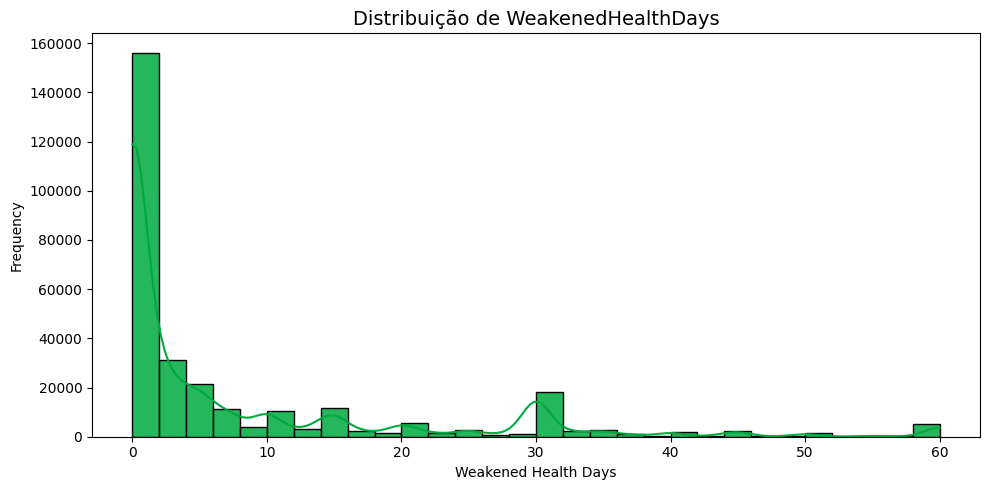

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_processed,
    x="WeakenedHealthDays",
    bins=30,
    kde=True,
    color=JADE,
    alpha=0.85
)

plt.title(
    "Distribuição de WeakenedHealthDays",
    fontsize=14
)

plt.xlabel("Weakened Health Days")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [46]:
# @title Atualizar as variaveis numéricas
numeric_columns = (
    df_processed
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

print(
    f"Quantidade de variáveis numéricas: "
    f"{len(numeric_columns)}"
)

Quantidade de variáveis numéricas: 5


In [47]:
print("WeakenedHealthDays" in numeric_columns)

True


## 11. Train/Test Split

In [48]:

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Dados separados com sucesso.")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Dados separados com sucesso.
X_train: (241373, 17)
X_test : (60344, 17)
y_train: (241373,)
y_test : (60344,)


In [49]:
# @title Verificar a proporção das classes

train_distribution = (
    y_train
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

distribution = pd.DataFrame({
    "Treino (%)": train_distribution,
    "Teste (%)": test_distribution
})

display(distribution)

,Treino (%),Teste (%)
HeartDisease,,
0,90.96,90.97
1,9.04,9.03


In [50]:
# @title Verificação das dimensões
split_summary = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "Registros": [len(X_train), len(X_test)],
    "Percentual": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})

split_summary["Percentual"] = split_summary["Percentual"].round(2)

display(split_summary)

,Conjunto,Registros,Percentual
0,Treino,241373,80.0
1,Teste,60344,20.0


**Estratégia de divisão:** Os dados foram divididos em 80% para treinamento e 20% para teste. Foi utilizada estratificação (stratify=y) para preservar a proporção das classes da variável alvo nos dois conjuntos. O random_state=42 garante a reprodutibilidade dos resultados. A divisão é realizada antes do ajuste dos transformadores, como codificadores e escaladores, evitando vazamento de informação entre treinamento e teste.

## 12. Escolanamento das Variáveis Numéricas

In [51]:
scaler = StandardScaler()

numeric_cols_for_scaling = [
    col for col in numeric_columns if col in X_train_processed.columns
]

X_train_scaled = scaler.fit_transform(
    X_train_processed[numeric_cols_for_scaling]
)

X_test_scaled = scaler.transform(
    X_test_processed[numeric_cols_for_scaling]
)

In [52]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=numeric_cols_for_scaling,
    index=X_train_processed.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=numeric_cols_for_scaling,
    index=X_test_processed.index
)

X_train_final = pd.concat(
    [
        X_train_scaled_df,
        X_train_encoded_df
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_scaled_df,
        X_test_encoded_df
    ],
    axis=1
)

In [53]:
scaling_summary = pd.DataFrame({
    "Mean": X_train_final[numeric_cols_for_scaling].mean(),
    "Std": X_train_final[numeric_cols_for_scaling].std()
})

display(
    scaling_summary.round(3)
)

,Mean,Std
BMI,-0.0,1.0
PhysicalHealth,0.0,1.0
MentalHealth,-0.0,1.0
SleepTime,-0.0,1.0


## 13. Balanceamento das Classes - SMOTE

In [54]:
# @title Verificar a distribuição original
print("Distribuição antes do SMOTE:")

display(
    y_train.value_counts()
    .sort_index()
)

Distribuição antes do SMOTE:


,count
HeartDisease,
0,219564
1,21809


In [55]:
display(
    y_train.value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

,proportion
HeartDisease,
0,90.96
1,9.04


In [56]:
# @title Aplicar SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_final,
    y_train
)

In [57]:
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_final,
    y_train
)

In [58]:
print("Distribuição após SMOTE:")

display(
    y_train_balanced.value_counts()
    .sort_index()
)

Distribuição após SMOTE:


,count
HeartDisease,
0,219564
1,219564


In [59]:
display(
    y_train_balanced.value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

,proportion
HeartDisease,
0,50.0
1,50.0


In [60]:
balance_comparison = pd.DataFrame({
    "Before SMOTE": y_train.value_counts(),
    "After SMOTE": y_train_balanced.value_counts()
})

display(
    balance_comparison
)

,Before SMOTE,After SMOTE
HeartDisease,,
0,219564,219564
1,21809,219564


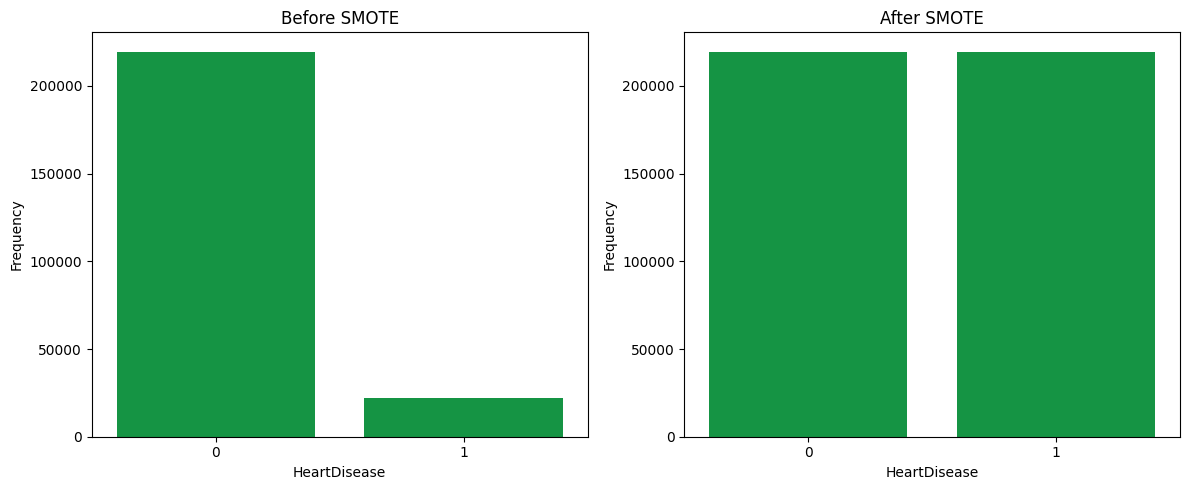

In [61]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.countplot(
    x=y_train,
    ax=axes[0],
    color=JADE
)

axes[0].set_title(
    "Before SMOTE"
)

axes[0].set_xlabel(
    "HeartDisease"
)

axes[0].set_ylabel(
    "Frequency"
)

sns.countplot(
    x=y_train_balanced,
    ax=axes[1],
    color=JADE
)

axes[1].set_title(
    "After SMOTE"
)

axes[1].set_xlabel(
    "HeartDisease"
)

axes[1].set_ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

## 14. Validação do Dataset Processado


In [62]:
# @title Dimensões
print("=" * 60)
print("DIMENSÕES FINAIS")
print("=" * 60)

print(
    f"X_train_balanced: {X_train_balanced.shape}"
)

print(
    f"y_train_balanced: {y_train_balanced.shape}"
)

print(
    f"X_test_final: {X_test_final.shape}"
)

print(
    f"y_test: {y_test.shape}"
)

DIMENSÕES FINAIS
X_train_balanced: (439128, 50)
y_train_balanced: (439128,)
X_test_final: (60344, 50)
y_test: (60344,)


In [63]:
# @title Valores ausentes
print("=" * 60)
print("VALORES AUSENTES")
print("=" * 60)
print(
    "Missing values - X_train:",
    X_train_balanced.isna().sum().sum()
)

print(
    "Missing values - X_test:",
    X_test_final.isna().sum().sum()
)

VALORES AUSENTES
Missing values - X_train: 0
Missing values - X_test: 0


In [64]:
# @title Verificar tipos
print("=" * 60)
print("TIPOS DE DADOS")
print("=" * 60)
print(
    X_train_balanced.dtypes.value_counts()
)

TIPOS DE DADOS
float64    50
Name: count, dtype: int64


In [65]:
# @title Verificar duplicados
print("=" * 60)
print("DUPLICADOS")
print("=" * 60)
print(
    "Duplicated rows - X_train:",
    X_train_balanced.duplicated().sum()
)

print(
    "Duplicated rows - X_test:",
    X_test_final.duplicated().sum()
)


DUPLICADOS
Duplicated rows - X_train: 733
Duplicated rows - X_test: 37


In [66]:
X_train_final.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_No,Smoking_Yes,AlcoholDrinking_No,AlcoholDrinking_Yes,Stroke_No,Stroke_Yes,DiffWalking_No,DiffWalking_Yes,Sex_Female,Sex_Male,AgeCategory_18-24,AgeCategory_25-29,AgeCategory_30-34,AgeCategory_35-39,AgeCategory_40-44,AgeCategory_45-49,AgeCategory_50-54,AgeCategory_55-59,AgeCategory_60-64,AgeCategory_65-69,AgeCategory_70-74,AgeCategory_75-79,AgeCategory_80 or older,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_No,PhysicalActivity_Yes,GenHealth_Excellent,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_No,Asthma_Yes,KidneyDisease_No,KidneyDisease_Yes,SkinCancer_No,SkinCancer_Yes
176113,0.474667,-0.439058,-0.137842,-0.056883,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6984,-1.067100,-0.439058,-0.506526,0.625866,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
207892,0.539616,1.277402,-0.506526,0.625866,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
260064,-0.600086,-0.439058,-0.506526,-0.056883,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
45725,1.359212,0.051359,-0.506526,-0.056883,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [67]:
X_test_final.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_No,Smoking_Yes,AlcoholDrinking_No,AlcoholDrinking_Yes,Stroke_No,Stroke_Yes,DiffWalking_No,DiffWalking_Yes,Sex_Female,Sex_Male,AgeCategory_18-24,AgeCategory_25-29,AgeCategory_30-34,AgeCategory_35-39,AgeCategory_40-44,AgeCategory_45-49,AgeCategory_50-54,AgeCategory_55-59,AgeCategory_60-64,AgeCategory_65-69,AgeCategory_70-74,AgeCategory_75-79,AgeCategory_80 or older,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_No,PhysicalActivity_Yes,GenHealth_Excellent,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_No,Asthma_Yes,KidneyDisease_No,KidneyDisease_Yes,SkinCancer_No,SkinCancer_Yes
33684,-0.399053,-0.439058,-0.506526,-0.056883,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
35118,-0.204205,-0.439058,-0.506526,-0.056883,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
26910,-0.562972,-0.439058,-0.260737,-0.056883,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
142348,-0.204205,-0.439058,-0.506526,-0.739633,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
179663,2.382933,1.400006,-0.506526,1.308616,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [68]:
X_train_balanced.head()


,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_No,Smoking_Yes,AlcoholDrinking_No,AlcoholDrinking_Yes,Stroke_No,Stroke_Yes,DiffWalking_No,DiffWalking_Yes,Sex_Female,Sex_Male,AgeCategory_18-24,AgeCategory_25-29,AgeCategory_30-34,AgeCategory_35-39,AgeCategory_40-44,AgeCategory_45-49,AgeCategory_50-54,AgeCategory_55-59,AgeCategory_60-64,AgeCategory_65-69,AgeCategory_70-74,AgeCategory_75-79,AgeCategory_80 or older,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_No,PhysicalActivity_Yes,GenHealth_Excellent,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_No,Asthma_Yes,KidneyDisease_No,KidneyDisease_Yes,SkinCancer_No,SkinCancer_Yes
0,0.474667,-0.439058,-0.137842,-0.056883,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,-1.067100,-0.439058,-0.506526,0.625866,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.539616,1.277402,-0.506526,0.625866,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
3,-0.600086,-0.439058,-0.506526,-0.056883,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,1.359212,0.051359,-0.506526,-0.056883,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [69]:
y_train_balanced.head()

,HeartDisease
0,0
1,0
2,0
3,0
4,0


In [70]:
# @title Dados para Tree/XGBoost
smote_tree = SMOTE(
    random_state=RANDOM_STATE
)

X_train_tree, y_train_tree = smote_tree.fit_resample(
    X_train_processed,
    y_train
)

X_test_tree = X_test_processed.copy()

In [71]:
# @title Dados para KNN
smote_knn = SMOTE(
    random_state=RANDOM_STATE
)

X_train_knn, y_train_knn = smote_knn.fit_resample(
    X_train_final,
    y_train
)

X_test_knn = X_test_final.copy()

## Salvar os Artefatos

In [72]:
# SALVAR X_train_knn.csv
X_train_knn.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/processed/X_train_knn.csv",
    index=False
)

In [73]:
# Salvar X_test_knn.csv
X_test_knn.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/processed/X_test_knn.csv",
    index=False
)

In [74]:
# salvar X_train_tree.csv
X_train_tree.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/processed/X_train_tree.csv",
    index=False
)

In [75]:
# salvar X_test_tree.csv
X_test_tree.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/processed/X_test_tree.csv",
    index=False
)

In [76]:
# salvar o y_train.csv
y_train.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/processed/y_train.csv",
    index=False
)

In [77]:
# salvar o y_test.csv
y_test.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/processed/y_test.csv",
    index=False
)

## Conclusão

O pré-processamento dos dados foi concluído seguindo uma sequência estruturada e reprodutível. Foram tratadas as inconsistências identificadas durante a análise exploratória, realizada a engenharia da variável WeakenedHealthDays, separadas as bases de treinamento e teste, codificadas as variáveis categóricas e escalonadas as variáveis numéricas.

O desbalanceamento da variável alvo foi tratado utilizando SMOTE exclusivamente no conjunto de treinamento, preservando o conjunto de teste para uma avaliação imparcial dos modelos.

Os transformadores utilizados no pré-processamento, incluindo o OneHotEncoder e o StandardScaler, foram persistidos para garantir a reprodutibilidade do pipeline e permitir sua utilização posteriormente durante a etapa de modelagem e inferência.

Ao final desta etapa, os dados encontram-se preparados para a construção e avaliação dos modelos de Machine Learning.